In [1]:
import pandas as pd

In [4]:
df = pd.read_csv("Students Social Media Addiction.csv")
df.head()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn. compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Target Variable
target = "Addicted_Score"

X = df.drop(columns=[target])
y = df [target]

# Split first (good practice)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Identify text columns vs numeric columns
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns
num_cols = X.select_dtypes(exclude=["object", "category", "bool"]).columns

# Preprocess: one-hot encode categorical, leave numeric alone
preprocess = ColumnTransformer(
  transformers=[
      ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
      ("num", "passthrough", num_cols)
  ]
)
# Build pipeline: preprocess -> model
model = Pipeline(steps=[
("preprocess", preprocess),
("model", DecisionTreeClassifier(random_state=42))
])

# Build pipeline: preprocess -> model
model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DecisionTreeClassifier(random_state=42))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted", zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average="weighted", zero_division=0))
print("F1:", f1_score(y_test, y_pred, average="weighted", zero_division=0))


Accuracy: 0.9645390070921985
Precision: 0.9604556200300882
Recall: 0.9645390070921985
F1: 0.9618195967872193


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn. compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Target variable
target = "Addicted_Score"

# Feature Engineering (new variable)
df_fe = df.copy()
df_fe["sleep_loss"] = 8 - df_fe["Sleep_Hours_Per_Night"]

X = df_fe.drop(columns=[target])
y = df_fe [target]

# Split first (good practice)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Identify text columns vs numeric columns
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns
num_cols = X.select_dtypes(exclude=["object", "category", "bool"]).columns

# Preprocess: one-hot encode categorical, leave numeric alone
preprocess = ColumnTransformer(
  transformers=[
      ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
      ("num", "passthrough", num_cols)
  ]
)
# Build pipeline: preprocess -> model
model = Pipeline(steps=[
("preprocess", preprocess),
("model", DecisionTreeClassifier(random_state=42))
])

# Build pipeline: preprocess -> model
model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", DecisionTreeClassifier(random_state=42))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted", zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average="weighted", zero_division=0))
print("F1:", f1_score(y_test, y_pred, average="weighted", zero_division=0))


Accuracy: 0.9645390070921985
Precision: 0.9604556200300882
Recall: 0.9645390070921985
F1: 0.9618195967872193


In [7]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error

target = "Addicted_Score"

X = df.drop(columns=[target])
y = df [target]

# Split first (good practice)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Identify text columns vs numeric columns
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns
num_cols = X.select_dtypes(exclude=["object", "category", "bool"]).columns

# Preprocess: one-hot encode categorical, leave numeric alone
preprocess = ColumnTransformer(
  transformers=[
      ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
      ("num", "passthrough", num_cols)
  ]
)

# Build pipeline: preprocess -> model
pipe = Pipeline([
    ("prep", preprocess),
    ("model", DecisionTreeRegressor(random_state=42))
])

param_grid = {
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

grid = GridSearchCV(pipe, param_grid, cv=5)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
preds = best_model.predict(X_test)

print("Best parameters:", grid.best_params_)
print("F1:", f1_score(y_test, y_pred, average="weighted"))
print("MAE:", mean_absolute_error(y_test, preds))

Best parameters: {'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5}
F1: 0.9618195967872193
MAE: 0.03959810874704491


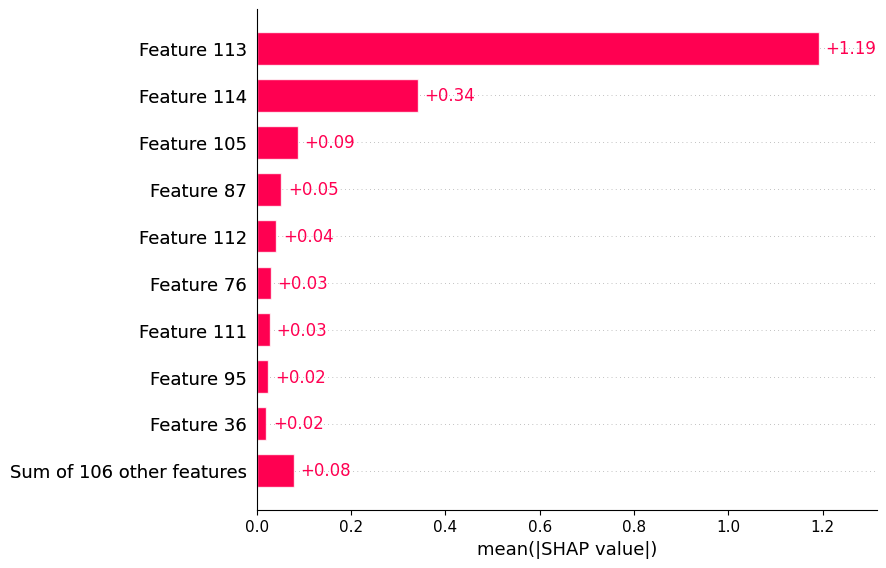

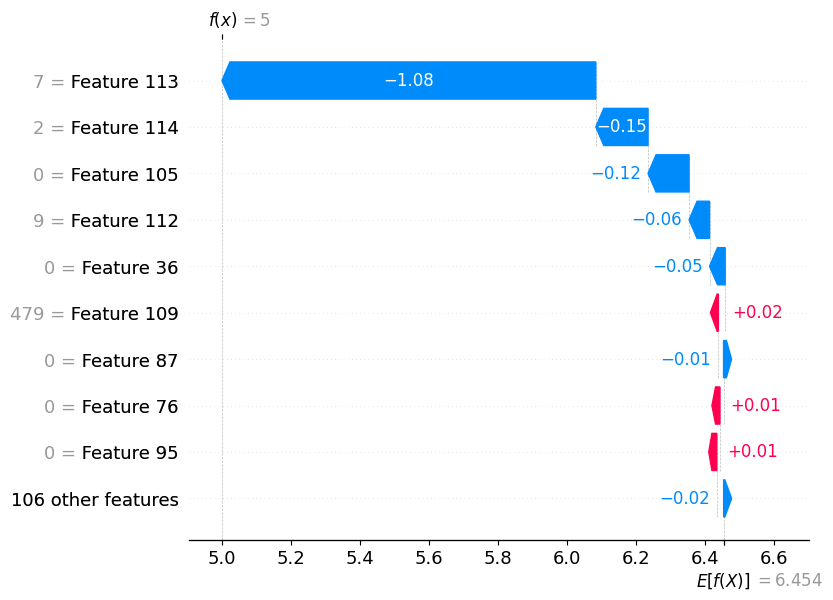

In [8]:
#EXPLAINABILITY

import shap

pipe = grid.best_estimator_

prep = pipe.named_steps["prep"]
tree = pipe.named_steps["model"]

X_test_proc = prep.transform(X_test)

if hasattr(X_test_proc, "toarray"):
    X_test_proc = X_test_proc.toarray()

explainer = shap.Explainer(tree)

sv = explainer(X_test_proc)

shap.plots.bar(sv)

shap.plots.waterfall(sv[0])

In [9]:
# CROSS VALIDATION

from sklearn.model_selection import cross_val_score
import numpy as np

cv_scores = cross_val_score(
    pipe,
    X,
    y,
    cv=5,
    scoring="neg_mean_absolute_error"
)

cv_mae = -cv_scores

print("Cross-Validation MAE scores:", cv_mae)
print("Average MAE:", cv_mae.mean())
print("Standard Deviation:", cv_mae.std())

Cross-Validation MAE scores: [0.37234043 0.21985816 0.         0.01241135 0.17021277]
Average MAE: 0.15496453900709223
Standard Deviation: 0.1385867141909133


In [12]:
# ERROR ANALYSIS
import pandas as pd
import numpy as np

#previous predictions
y_pred = best_model.predict(X_test)

# calculate errors
errors = y_test - y_pred

error_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
    "Error": errors,
    "Absolute Error": np.abs(errors)
    })

# worst predictions

error_df.sort_values(by="Absolute Error", ascending=False).head(10)

,Actual,Predicted,Error,Absolute Error
54,5,6.000000,-1.000000,1.000000
6,2,3.000000,-1.000000,1.000000
10,7,8.000000,-1.000000,1.000000
579,6,7.000000,-1.000000,1.000000
55,7,7.500000,-0.500000,0.500000
41,8,8.500000,-0.500000,0.500000
584,4,4.333333,-0.333333,0.333333
158,8,7.750000,0.250000,0.250000
319,4,4.000000,0.000000,0.000000
81,7,7.000000,0.000000,0.000000


In [13]:
print("Average absolute error:", error_df["Absolute Error"].mean())
print("Max absolute error:", error_df["Absolute Error"].max())

Average absolute error: 0.03959810874704491
Max absolute error: 1.0
